# Before you start :
   - These exercises are related to the Subsetting and Descriptive Stats lessons.
   - Keep in mind that you need to use some of the functions you learned in the previous lessons.
   - All datasets are provided in the `your-code` folder of this lab.
   - Elaborate your codes and outputs as much as you can.
   - Try your best to answer the questions and complete the tasks and most importantly enjoy the process!!!

#### Import all the libraries that are necessary

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns

# Challenge 1

#### In this challenge we will use the `Temp_States.csv` file. 

#### First import it into a data frame called `temp`.

In [3]:
df = pd.read_csv(r"C:\Users\torre\Desktop\IronHack\Labs\Week 4\PreWork\lab-descriptive-stats-en-main\your-code\Temp_States.csv")

#### Print `temp`

In [9]:
temp = pd.read_csv(r"C:\Users\torre\Desktop\IronHack\Labs\Week 4\PreWork\lab-descriptive-stats-en-main\your-code\Temp_States.csv")
print (temp)


         City        State  Temperature
0         NYC     New York    19.444444
1      Albany     New York     9.444444
2     Buffalo     New York     3.333333
3    Hartford  Connecticut    17.222222
4  Bridgeport  Connecticut    14.444444
5      Treton   New Jersey    22.222222
6      Newark   New Jersey    20.000000


#### Explore the data types of the Temp dataframe. What type of data do we have? Comment your result.

In [ ]:
# The data types of the Temp df has city as object, state as object, and temperature as float. It contains geographic and temperature related
# information. 


#### Select the rows where state is New York

In [17]:
new_york_data = temp[temp['State'] == 'New York']
print(new_york_data)

      City     State  Temperature
0      NYC  New York    19.444444
1   Albany  New York     9.444444
2  Buffalo  New York     3.333333


#### What is the average of the temperature of cities in New York?

In [19]:
average_temperature_ny = new_york_data['Temperature'].mean()

print(f"The average temperature of cities in New York is {average_temperature_ny:.2f}")

The average temperature of cities in New York is 10.74


#### We want to know cities and states with Temperature above 15 degress Celcius

In [23]:
high_temp_data = temp[temp['Temperature'] > 15]

print("Cities and States with Temperature Above 15°C:")
print(high_temp_data)

Cities and States with Temperature Above 15°C:
       City        State  Temperature
0       NYC     New York    19.444444
3  Hartford  Connecticut    17.222222
5    Treton   New Jersey    22.222222
6    Newark   New Jersey    20.000000


#### Now, return only the cities that have a temperature above 15 degress Celcius

In [25]:
cities_above_15 = high_temp_data['City']

print("Cities with Temperature Above 15°C:")
print(cities_above_15.tolist())

Cities with Temperature Above 15°C:
['NYC', 'Hartford', 'Treton', 'Newark']


#### We want to know which cities have a temperature above 15 degrees Celcius and below 20 degrees Celcius

*Hint: First write the condition then select the rows.*

In [29]:
cities_temp_15_20 = temp[(temp['Temperature'] > 15) & (temp['Temperature'] < 20)]

print("Cities with Temperature Above 15°C and Below 20°C:")
print(cities_temp_15_20['City'].tolist())

Cities with Temperature Above 15°C and Below 20°C:
['NYC', 'Hartford']


In [31]:
temp['State'].value_counts()

State
New York       3
Connecticut    2
New Jersey     2
Name: count, dtype: int64

#### Find the mean and the standard deviation of the temperature of each state.

*Hint: Use functions from Data Manipulation lesson*

In [37]:
state_temp_stats = temp.groupby('State')['Temperature'].agg(['mean', 'std']).reset_index()
print (state_temp_stats)

         State       mean       std
0  Connecticut  15.833333  1.964186
1   New Jersey  21.111111  1.571348
2     New York  10.740741  8.133404


# Challenge 2

#### Load the `employee.csv` file into a DataFrame. Call the dataframe `employee`

In [41]:
df = pd.read_csv(r"C:\Users\torre\Desktop\IronHack\Labs\Week 4\PreWork\lab-descriptive-stats-en-main\your-code\Employee.csv")
employee_data = pd.read_csv(r"C:\Users\torre\Desktop\IronHack\Labs\Week 4\PreWork\lab-descriptive-stats-en-main\your-code\Employee.csv")

#### Explore the data types of the Temp dataframe. Comment your results

In [ ]:
# The data types in the employee df are starting with the name ad object, department as object, education as object,
# gender as object, tittle as object, salary as int 64, and years at int64. This dataset is good for descriptive analytics with comparatives. 

#### Show visually the frequency distribution (histogram) of the employee dataset. In few words describe these histograms?

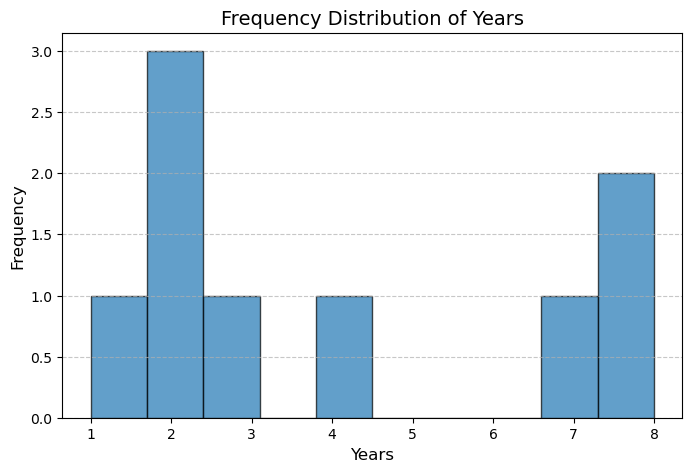

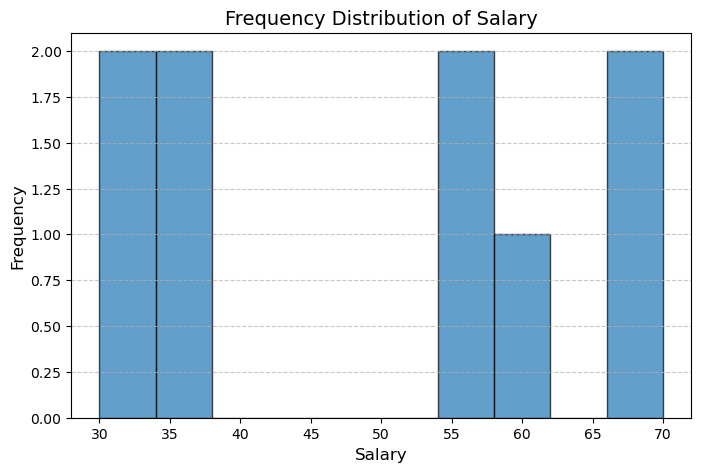

In [43]:
numeric_columns = employee_data.select_dtypes(include=['int64']).columns
for column in numeric_columns:
    plt.figure(figsize=(8, 5))
    plt.hist(employee_data[column], bins=10, edgecolor='black', alpha=0.7)
    plt.title(f'Frequency Distribution of {column}', fontsize=14)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

In [ ]:
# With this data we can see how there's employees who have a higher salary than years in the company. 

#### What's the average salary in this company?

In [45]:
average_salary = employee_data['Salary'].mean()
print(f"The average salary in the company is ${average_salary:.2f}")

The average salary in the company is $48.89


#### What's the highest salary?

In [47]:
highest_salary = employee_data['Salary'].max()

print(f"The highest salary in the company is ${highest_salary}")

The highest salary in the company is $70


#### What's the lowest salary?

In [49]:
lowest_salary = employee_data['Salary'].min()

print(f"The lowest salary in the company is ${lowest_salary}")

The lowest salary in the company is $30


#### Who are the employees with the lowest salary?

In [51]:
employees_with_lowest_salary = employee_data[employee_data['Salary'] == employee_data['Salary'].min()]

print("Employees with the Lowest Salary:")
print(employees_with_lowest_salary)

Employees with the Lowest Salary:
    Name Department Education Gender    Title  Years  Salary
1  Maria         IT    Master      F  analyst      2      30
2  David         HR    Master      M  analyst      2      30


#### Could you give all the information about an employee called David?

In [53]:
employee_david = employee_data[employee_data['Name'] == 'David']

print("Information About Employee David:")
print(employee_david)

Information About Employee David:
    Name Department Education Gender    Title  Years  Salary
2  David         HR    Master      M  analyst      2      30


#### Could you give only David's salary?

In [55]:
david_salary = employee_data.loc[employee_data['Name'] == 'David', 'Salary'].values[0]

print(f"David's salary is ${david_salary}")

David's salary is $30


#### Print all the rows where job title is associate

In [57]:
associate_rows = employee_data[employee_data['Title'] == 'associate']

print("Rows Where Job Title is Associate:")
print(associate_rows)

Rows Where Job Title is Associate:
     Name Department Education Gender      Title  Years  Salary
4  Samuel      Sales    Master      M  associate      3      55
5     Eva      Sales  Bachelor      F  associate      2      55
7   Pedro         IT       Phd      M  associate      7      60


#### Print the first 3 rows of your dataframe

##### Tip : There are 2 ways to do it. Do it both ways

In [59]:
print("First 3 rows of the dataframe:")
print(employee_data.head(3))

First 3 rows of the dataframe:
    Name Department Education Gender    Title  Years  Salary
0   Jose         IT  Bachelor      M  analyst      1      35
1  Maria         IT    Master      F  analyst      2      30
2  David         HR    Master      M  analyst      2      30


#### Find the employees who's title is associate and the salary above 55?

In [61]:
associates_high_salary = employee_data[(employee_data['Title'] == 'associate') & (employee_data['Salary'] > 55)]

print("Associates with Salary Above 55:")
print(associates_high_salary)

Associates with Salary Above 55:
    Name Department Education Gender      Title  Years  Salary
7  Pedro         IT       Phd      M  associate      7      60


#### Group the employees based on their number of years of employment. What are the average salaries in each group?

In [63]:
average_salary_by_years = employee_data.groupby('Years')['Salary'].mean().reset_index()

print("Average Salary by Years of Employment:")
print(average_salary_by_years)

Average Salary by Years of Employment:
   Years     Salary
0      1  35.000000
1      2  38.333333
2      3  55.000000
3      4  35.000000
4      7  60.000000
5      8  70.000000


####  What is the average Salary per title?

In [65]:
average_salary_by_title = employee_data.groupby('Title')['Salary'].mean().reset_index()

print("Average Salary by Title:")
print(average_salary_by_title)

Average Salary by Title:
       Title     Salary
0         VP  70.000000
1    analyst  32.500000
2  associate  56.666667


#### Show a visual summary of the data using boxplot. What Are the First and Third Quartiles? Comment your results.

* Hint : Quantiles vs Quartiles*
In Probability and Statistics, quantiles are cut points dividing the range of a probability distribution into continuous intervals with equal probabilities. When division is into four parts the values of the variate corresponding to 25%, 50% and 75% of the total distribution are called quartiles.

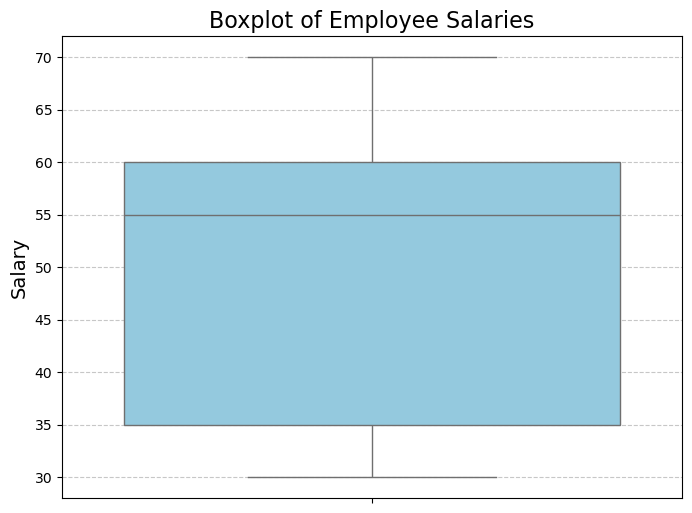

In [69]:
plt.figure(figsize=(8, 6))
sns.boxplot(data=employee_data, y='Salary', color='skyblue')
plt.title('Boxplot of Employee Salaries', fontsize=16)
plt.ylabel('Salary', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

q1 = employee_data['Salary'].quantile(0.25)
q3 = employee_data['Salary'].quantile(0.75)

In [73]:
print(f"First Quartile (Q1): ${q1:.2f}")

First Quartile (Q1): $35.00


In [71]:
print(f"Third Quartile (Q3): ${q3:.2f}")

Third Quartile (Q3): $60.00


#### Is the mean salary per gender different?

In [75]:
mean_salary_by_gender = employee_data.groupby('Gender')['Salary'].mean().reset_index()

print("Mean Salary by Gender:")
print(mean_salary_by_gender)

Mean Salary by Gender:
  Gender  Salary
0      F    47.5
1      M    50.0


#### Find the minimum, mean and the maximum of all numeric columns for each Department.

##### Hint: Use functions from Data Manipulation lesson

In [83]:
numeric_columns = employee_data.select_dtypes(include=['int64', 'float64']).columns

dept_stats = employee_data.groupby('Department')[numeric_columns].agg(['min', 'mean', 'max']).reset_index()

print("Minimum, Mean, and Maximum of Numeric Columns by Department:")
print(dept_stats)

Minimum, Mean, and Maximum of Numeric Columns by Department:
  Department Years               Salary           
               min      mean max    min   mean max
0         HR     2  4.666667   8     30  45.00  70
1         IT     1  4.500000   8     30  48.75  70
2      Sales     2  2.500000   3     55  55.00  55


### Bonus Question

#### For each department, compute the difference between the maximal salary and the minimal salary.

##### * Hint: try using `agg` or `apply` and `lambda`*

In [87]:
salary_range_by_department = employee_data.groupby('Department')['Salary'].agg(
    lambda x: x.max() - x.min()
).reset_index()

salary_range_by_department.rename(columns={'Salary': 'Salary Range'}, inplace=True)

print("Salary Range by Department:")
print(salary_range_by_department)


Salary Range by Department:
  Department  Salary Range
0         HR            40
1         IT            40
2      Sales             0


# Challenge 3

#### Open the Orders.csv dataset. Name your dataset orders

In [91]:
df = pd.read_csv(r"C:\Users\torre\Desktop\IronHack\Labs\Week 4\PreWork\lab-descriptive-stats-en-main\your-code\Orders.csv")
orders_data = pd.read_csv(r"C:\Users\torre\Desktop\IronHack\Labs\Week 4\PreWork\lab-descriptive-stats-en-main\your-code\Orders.csv")

#### Explore your dataset by looking at the data types and the summary statistics. Comment your results

In [ ]:
The dataset includes a mix of numeric (int64, float64) and object (categorical or string) data types.
Key numeric columns include Quantity, UnitPrice, CustomerID, and amount_spent.
Categorical columns include StockCode, Description, and Country.

In [ ]:
# This data set has a mix of ints, floats, and objects data types. Numeric columns include the quantity, unitprice,
# customerid, and amount_spend. The categorical include stockcode, description, and country. 

####  What is the average Purchase Price?

In [93]:
average_purchase_price = orders_data['UnitPrice'].mean()

print(f"The average purchase price is ${average_purchase_price:.2f}")

The average purchase price is $3.12


#### What were the highest and lowest purchase prices? 

In [95]:
highest_purchase_price = orders_data['UnitPrice'].max()
lowest_purchase_price = orders_data['UnitPrice'].min()

print(f"The highest purchase price is ${highest_purchase_price:.2f}")
print(f"The lowest purchase price is ${lowest_purchase_price:.2f}")

The highest purchase price is $8142.75
The lowest purchase price is $0.00


#### Select all the customers we have in Spain

In [97]:
customers_in_spain = orders_data[orders_data['Country'] == 'Spain']

print("Customers in Spain:")
print(customers_in_spain)

Customers in Spain:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
4250          6421     536944     22383  2010     12    5    12   
4251          6422     536944     22384  2010     12    5    12   
4252          6423     536944     20727  2010     12    5    12   
4253          6424     536944     20725  2010     12    5    12   
4254          6425     536944     20728  2010     12    5    12   
...            ...        ...       ...   ...    ...  ...   ...   
394733      535271     581193     23291  2011     12    3    17   
394734      535272     581193    85232D  2011     12    3    17   
394735      535273     581193     22721  2011     12    3    17   
394736      535274     581193     23241  2011     12    3    17   
394737      535275     581193     23247  2011     12    3    17   

                          Description  Quantity          InvoiceDate  \
4250          lunch bag suki  design         70  2010-12-03 12:20:00   
4251          lunch bag pink po

#### How many customers do we have in Spain?
##### Hint : Use value_counts()

In [99]:
num_customers_in_spain = orders_data[orders_data['Country'] == 'Spain']['CustomerID'].nunique()

print(f"The number of unique customers in Spain is {num_customers_in_spain}.")

The number of unique customers in Spain is 30.


#### Select all the customers who have bought more than 50 items ?

In [101]:
customers_more_than_50_items = orders_data[orders_data['Quantity'] > 50]

print("Customers Who Bought More Than 50 Items:")
print(customers_more_than_50_items)

Customers Who Bought More Than 50 Items:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
46              46     536371     22086  2010     12    3     9   
83              83     536376     21733  2010     12    3     9   
96              96     536378     21212  2010     12    3     9   
102            102     536378    85071B  2010     12    3     9   
174            176     536386    85099C  2010     12    3     9   
...            ...        ...       ...   ...    ...  ...   ...   
397720      541702     581566     23404  2011     12    5    11   
397721      541703     581567     21417  2011     12    5    11   
397729      541711     581567     21326  2011     12    5    11   
397761      541746     581571     23167  2011     12    5    12   
397882      541867     581584     20832  2011     12    5    12   

                               Description  Quantity          InvoiceDate  \
46         paper chain kit 50's christmas         80  2010-12-01 09:00:00   


#### Select orders from Spain that are above 50 items

In [103]:
orders_spain_above_50 = orders_data[(orders_data['Country'] == 'Spain') & (orders_data['Quantity'] > 50)]

print("Orders from Spain with more than 50 items:")
print(orders_spain_above_50)

Orders from Spain with more than 50 items:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
4250          6421     536944     22383  2010     12    5    12   
4251          6422     536944     22384  2010     12    5    12   
4252          6423     536944     20727  2010     12    5    12   
4253          6424     536944     20725  2010     12    5    12   
4254          6425     536944     20728  2010     12    5    12   
32454        52416     540785    84997B  2011      1    2    11   
32455        52417     540785    84997D  2011      1    2    11   
32456        52418     540785    84997C  2011      1    2    11   
32457        52419     540785    84997A  2011      1    2    11   
91155       136767     547972     22383  2011      3    1    16   
91156       136768     547972     22384  2011      3    1    16   
91159       136771     547972     20728  2011      3    1    16   
174442      248797     558871     22384  2011      7    1    13   
174443      248798 

#### Select all free orders

In [105]:
free_orders = orders_data[orders_data['UnitPrice'] == 0]

print("Free Orders:")
print(free_orders)

Free Orders:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
6914          9302     537197     22841  2010     12    7    14   
22539        33576     539263     22580  2010     12    4    14   
25379        40089     539722     22423  2010     12    2    13   
29080        47068     540372     22090  2011      1    4    16   
29082        47070     540372     22553  2011      1    4    16   
34494        56674     541109     22168  2011      1    4    15   
53788        86789     543599    84535B  2011      2    4    13   
85671       130188     547417     22062  2011      3    3    10   
92875       139453     548318     22055  2011      3    3    12   
97430       145208     548871     22162  2011      4    1    14   
107192      157042     550188     22636  2011      4    4    18   
128641      187613     553000     47566  2011      5    4    15   
137127      198383     554037     22619  2011      5    5    14   
194648      279324     561284     22167  2011    

#### Select all orders that are 'lunch bag'
#### Hint: Use string functions

In [109]:
lunch_bag_orders = orders_data[orders_data['Description'].str.contains('lunch bag', case=False, na=False)]

print("Lunch Bag Orders:")
print(lunch_bag_orders)

Lunch Bag Orders:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
93              93     536378     20725  2010     12    3     9   
172            174     536385     22662  2010     12    3     9   
354            363     536401     22662  2010     12    3    11   
359            368     536401     20725  2010     12    3    11   
360            369     536401     22382  2010     12    3    11   
...            ...        ...       ...   ...    ...  ...   ...   
397465      540436     581486     23207  2011     12    5     9   
397713      541695     581538     20727  2011     12    5    11   
397714      541696     581538     20725  2011     12    5    11   
397877      541862     581581     23681  2011     12    5    12   
397880      541865     581583     20725  2011     12    5    12   

                        Description  Quantity          InvoiceDate  UnitPrice  \
93          lunch bag red retrospot        10  2010-12-01 09:37:00       1.65   
172     lunch b

#### Select all orders that are made in 2011 and are 'lunch bag'  

In [111]:
lunch_bag_2011_orders = orders_data[(orders_data['Description'].str.contains('lunch bag', case=False, na=False)) & (orders_data['year'] == 2011)]

print("Lunch Bag Orders in 2011:")
print(lunch_bag_2011_orders)

Lunch Bag Orders in 2011:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
26340        42678     540015     20725  2011      1    2    11   
26341        42679     540015     20726  2011      1    2    11   
26512        42851     540023     22382  2011      1    2    12   
26513        42852     540023     20726  2011      1    2    12   
26860        43616     540098     22384  2011      1    2    15   
...            ...        ...       ...   ...    ...  ...   ...   
397465      540436     581486     23207  2011     12    5     9   
397713      541695     581538     20727  2011     12    5    11   
397714      541696     581538     20725  2011     12    5    11   
397877      541862     581581     23681  2011     12    5    12   
397880      541865     581583     20725  2011     12    5    12   

                        Description  Quantity          InvoiceDate  UnitPrice  \
26340       lunch bag red retrospot        10  2011-01-04 11:40:00       1.65   
26341  

#### Show the frequency distribution of the amount spent in Spain.

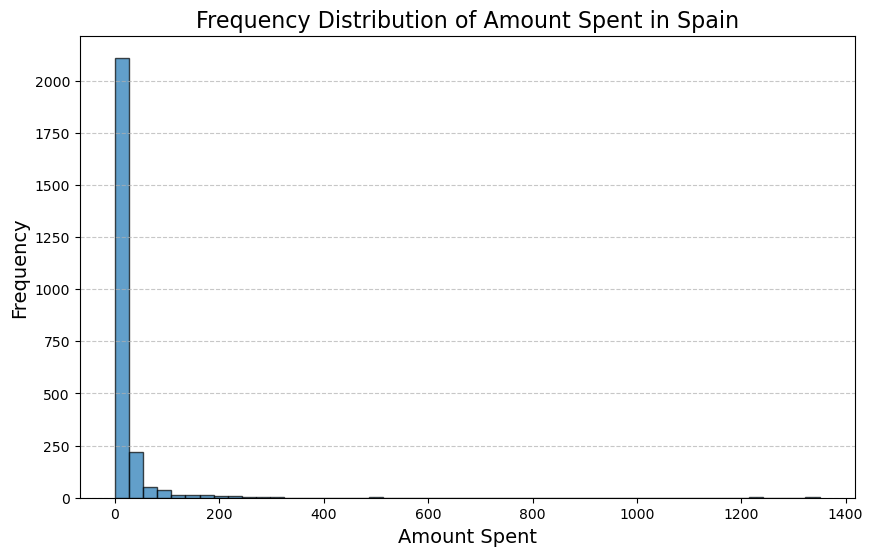

In [113]:
orders_spain = orders_data[orders_data['Country'] == 'Spain']

plt.figure(figsize=(10, 6))
plt.hist(orders_spain['amount_spent'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Frequency Distribution of Amount Spent in Spain', fontsize=16)
plt.xlabel('Amount Spent', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### Select all orders made in the month of August

In [115]:
august_orders = orders_data[orders_data['month'] == 8]

print("Orders made in August:")
print(august_orders)

Orders made in August:
        Unnamed: 0  InvoiceNo StockCode  year  month  day  hour  \
199475      285421     561904     22075  2011      8    1     8   
199476      285422     561904    85049E  2011      8    1     8   
199477      285423     561905     21385  2011      8    1     9   
199478      285424     561905    84970L  2011      8    1     9   
199479      285425     561905    84970S  2011      8    1     9   
...            ...        ...       ...   ...    ...  ...   ...   
226483      320688     565067     22644  2011      8    3    17   
226484      320689     565067     22645  2011      8    3    17   
226485      320690     565067     22637  2011      8    3    17   
226486      320691     565067     22646  2011      8    3    17   
226487      320692     565067     22741  2011      8    3    17   

                                Description  Quantity          InvoiceDate  \
199475         6 ribbons elegant christmas         96  2011-08-01 08:30:00   
199476          

#### Select how many orders are made by countries in the month of August
##### Hint: Use value_counts()

In [117]:
august_orders = orders_data[orders_data['month'] == 8]

orders_by_country_august = august_orders.groupby('Country').size().reset_index(name='Order Count')

print("Orders by Country in August:")
print(orders_by_country_august)

Orders by Country in August:
            Country  Order Count
0         Australia          107
1           Austria           88
2           Belgium          194
3            Canada            5
4   Channel Islands          140
5           Denmark           16
6              EIRE          593
7           Finland           61
8            France          569
9           Germany          795
10          Iceland           22
11           Israel          171
12            Italy           95
13            Malta           55
14      Netherlands          280
15           Norway           77
16           Poland           17
17         Portugal           41
18            Spain          252
19           Sweden           40
20      Switzerland          267
21   United Kingdom        23105
22      Unspecified           23


#### What's the  average amount of money spent by country

In [119]:
average_amount_spent_by_country = orders_data.groupby('Country')['amount_spent'].mean().reset_index()

print("Average Amount Spent by Country:")
print(average_amount_spent_by_country)

Average Amount Spent by Country:
                 Country  amount_spent
0              Australia    116.895620
1                Austria     25.624824
2                Bahrain     32.258824
3                Belgium     20.283772
4                 Brazil     35.737500
5                 Canada     24.280662
6        Channel Islands     27.340160
7                 Cyprus     22.134169
8         Czech Republic     33.069600
9                Denmark     49.882474
10                  EIRE     36.687745
11    European Community     21.670833
12               Finland     32.913985
13                France     25.056827
14               Germany     25.311562
15                Greece     32.831172
16               Iceland     23.681319
17                Israel     29.119718
18                 Italy     23.064960
19                 Japan    116.561900
20               Lebanon     37.641778
21             Lithuania     47.458857
22                 Malta     24.335625
23           Netherlands    120

#### What's the most expensive item?

In [121]:
most_expensive_item = orders_data.loc[orders_data['UnitPrice'].idxmax()]

print(f"The most expensive item is:")
print(most_expensive_item)

The most expensive item is:
Unnamed: 0                   173382
InvoiceNo                    551697
StockCode                      POST
year                           2011
month                             5
day                               2
hour                             13
Description                 postage
Quantity                          1
InvoiceDate     2011-05-03 13:46:00
UnitPrice                   8142.75
CustomerID                    16029
Country              United Kingdom
amount_spent                8142.75
Name: 118352, dtype: object


#### What was the average amount spent per year ?

In [ ]:
# your answer here